In [53]:
import sys, os
import os
os.chdir("/Users/samstephenson/Downloads/capy-bara")

import pipeline.metrics as metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import gerrychain.grid
import random
from collections import deque
import warnings
import tqdm
from collections import deque, defaultdict
import math

In [54]:
g = gerrychain.Graph.from_json("reproduction_data/ia_files/ia_counties_2020.json")

In [55]:
pos = {
    node: (
        float(g.nodes[node]["INTPTLON"]),
        math.degrees(math.log(math.tan(math.pi/4 + math.radians(float(g.nodes[node]["INTPTLAT"]))/2)))
    )
    for node in g.nodes()
}

pop = {
    node: g.nodes[node]["TOTPOP"]
    for node in g.nodes()
}

sizes = [pop[n] / 500 for n in g.nodes]  # adjust scaling factor

In [56]:
def visualize_iowa(g):
    fig, ax = plt.subplots(figsize=(10, 10))

    node_rhos = [g.nodes[node]["x_pop"] / g.nodes[node]["TOTPOP"] for node in g.nodes()]

    nx.draw_networkx_edges(g, pos=pos, edge_color="black", width=0.2, alpha=0.5, ax=ax)
    nx.draw_networkx_nodes(g, pos=pos, node_size=sizes, node_color=node_rhos,
                            cmap=plt.cm.Blues, vmin=0, vmax=1,
                            edgecolors='black', linewidths=0.5, ax=ax)

    ax.set_aspect('equal')
    ax.axis('off')

    plt.show()

In [57]:
def plot_rho_colorbar(vmin=0, vmax=1, tick_size=10):
    fig, ax = plt.subplots(figsize=(0.5, 4))
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, cax=ax)
    cbar.ax.tick_params(labelsize=tick_size)
    cbar.ax.set_title('ρ', rotation=0, fontsize=tick_size * 3, pad = 10)
    plt.tight_layout()
    plt.show()


In [58]:
def make_uniform_iowa(g, rho):
    for node in g.nodes():
        g.nodes[node]["x_pop"] = rho * g.nodes[node]['TOTPOP']
        g.nodes[node]["y_pop"]  = (1-rho) * g.nodes[node]['TOTPOP']
    return g

In [59]:
def plot_rho_vs_capy_uniform(g):
    num_rhos = 50

    rhos = np.linspace(0.001,0.5, num_rhos)

    # data lists for scores
    hcaps = np.zeros(num_rhos)
    ecaps = np.zeros(num_rhos)

    for i in range(num_rhos):
        g1 = g.copy()
        g1 = make_uniform_iowa(g1, rhos[i])
        hcaps[i] = metrics.half_edge(g1, "x_pop", "y_pop")
        ecaps[i] = metrics.edge(g1, "x_pop", "y_pop")

    plt.scatter(rhos,hcaps,s=1,c='b')
    plt.xlabel(u"\u03C1")
    plt.xlim([0,0.5])
    plt.ylim([0,1])
    plt.ylabel('Capy')

    plt.tight_layout()
    plt.show()


/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_16815/4277724053.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


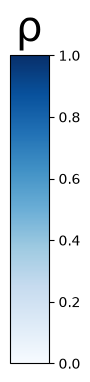

In [60]:
plot_rho_colorbar()

In [61]:
def property_sum(graph: gerrychain.Graph, col: str) -> float:
    cummulative = 0
    for node in graph.nodes():
        cummulative += int(graph.nodes[node][col])
    return cummulative

In [62]:
def populate_cluster(G, rho, seed=None):
    """
    Build a connected X-cluster whose total population is ~x_pop_fraction of total.
    X nodes: x_pop = TOTPOP, y_pop = 0
    Y nodes: x_pop = 0, y_pop = TOTPOP
    """

    nodes = list(G.nodes())

    if seed is None:
        seed = random.choice(nodes)

    # total population in graph
    total_pop = property_sum(G, "TOTPOP")
    target_x_pop = rho * total_pop

    x_nodes = set([seed])
    queue = deque([seed])

    current_x_pop = G.nodes[seed].get("TOTPOP", 0)

    while queue and current_x_pop < target_x_pop:
        u = queue.popleft()

        neighbors = list(G.neighbors(u))
        random.shuffle(neighbors)

        for v in neighbors:
            if v not in x_nodes:
                x_nodes.add(v)
                queue.append(v)

                current_x_pop += G.nodes[v].get("TOTPOP", 0)

                if current_x_pop >= target_x_pop:
                    break

    # assign populations
    for n in G.nodes():
        pop = G.nodes[n].get("TOTPOP", 0)

        if n in x_nodes:
            G.nodes[n]["x_pop"] = pop
            G.nodes[n]["y_pop"] = 0
        else:
            G.nodes[n]["x_pop"] = 0
            G.nodes[n]["y_pop"] = pop
        
    real_rho =  current_x_pop / total_pop
    
    return G, real_rho

In [104]:
def populate_cluster_random(start_node, G, tot_x_pop):
    

    queue = deque([start_node])

    visited = set()
    x_pop_sum = 0

    while queue and x_pop_sum < tot_x_pop:
        queue = list(queue)
        random.shuffle(queue)
        queue = deque(queue)
        node = queue.popleft()

        if node in visited or G.nodes[node]["x_pop"] > 0:
            visited.add(node)
            continue
        visited.add(node)

        # assign values
        G.nodes[node]["x_pop"] = G.nodes[node]["TOTPOP"]
        G.nodes[node]["y_pop"] = 0

        x_pop_sum += G.nodes[node]["TOTPOP"]

        # add neighbors (randomized expansion)
        neighbors = list(G.neighbors(node))
        random.shuffle(neighbors)

        for nbr in neighbors:
            if nbr not in visited:
                queue.append(nbr)


    for node in G.nodes():
        if G.nodes[node]["x_pop"] == 0:
            G.nodes[node]["y_pop"] = G.nodes[node]["TOTPOP"]

    real_rho = property_sum(g, "x_pop")/property_sum(g, "TOTPOP")
    
    return G, real_rho

In [105]:
def valid_isolated_config(g, column):
    nodes_in_cluster = []
    i=0
    for node in g.nodes():
        if g.nodes[node][column] >0:
            nodes_in_cluster.append(node)
        i+=1
    
    # should have as many connected components as there are nonzero entries
    if nx.number_connected_components(g.subgraph(nodes_in_cluster)) == np.count_nonzero([g.nodes[node]["x_pop"] for node in g.nodes]):
        return True
    else:
        return False

In [106]:
def make_random_isolated_config(g, rho):
    # reset populations
    for node in g.nodes():
        g.nodes[node]["x_pop"] = 0
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"]

    selected = set()
    blocked = set()

    nodes = list(g.nodes())
    random.shuffle(nodes)

    for node in nodes:
        if node in blocked:
            continue

        selected.add(node)
        blocked.add(node)
        blocked.update(g.neighbors(node))

        g.nodes[node]["x_pop"] = g.nodes[node]["TOTPOP"]
        g.nodes[node]["y_pop"] = 0
        current_rho = property_sum(g, "x_pop") / property_sum(g, "TOTPOP")
        if current_rho >= rho:
            break

    for node in g.nodes():
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"] - g.nodes[node]["x_pop"]
        

    return g, property_sum(g, "x_pop") / property_sum(g, "TOTPOP")

In [107]:
def generate_kclust_grid(n, m, rho, M, k):
    #grid_init
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["x_pop"] = 0
        G.graph.nodes[node]["y_pop"] = 0

    target_nodes = int((rho * n * m) / k)
    seeds = random.sample(list(G.graph.nodes), k)

    # remove seeds = random.sample(...) above the loop

    for i in range(k):
        y_nodes = [node for node in G.graph.nodes() if G.graph.nodes[node]["x_pop"] == 0]
        seed = random.choice(y_nodes)
        G = populate_cluster_random(seed, G, M, target_nodes*M)

    for node in G.graph.nodes():
        if G.graph.nodes[node]["x_pop"] == 0:
            G.graph.nodes[node]["y_pop"] = M
    
    real_rho = (metrics.property_sum(G.graph, "x_pop") / 
                (metrics.property_sum(G.graph, "x_pop") + 
                 metrics.property_sum(G.graph, "y_pop")))
    
    x_nodes = [
        node for node in G.graph.nodes()
        if G.graph.nodes[node]["x_pop"] > 0
        ]

    H = G.graph.subgraph(x_nodes)

    components = nx.number_connected_components(H)

    return (G, real_rho, components)

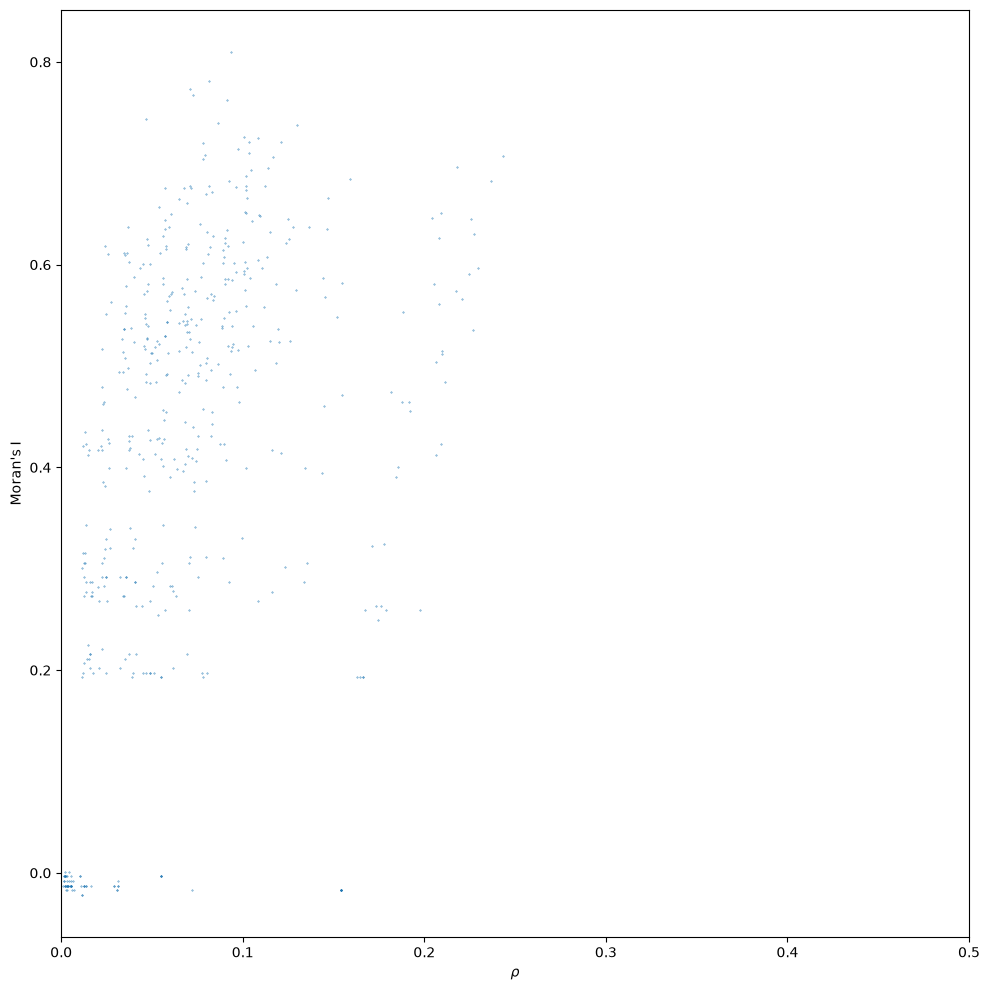

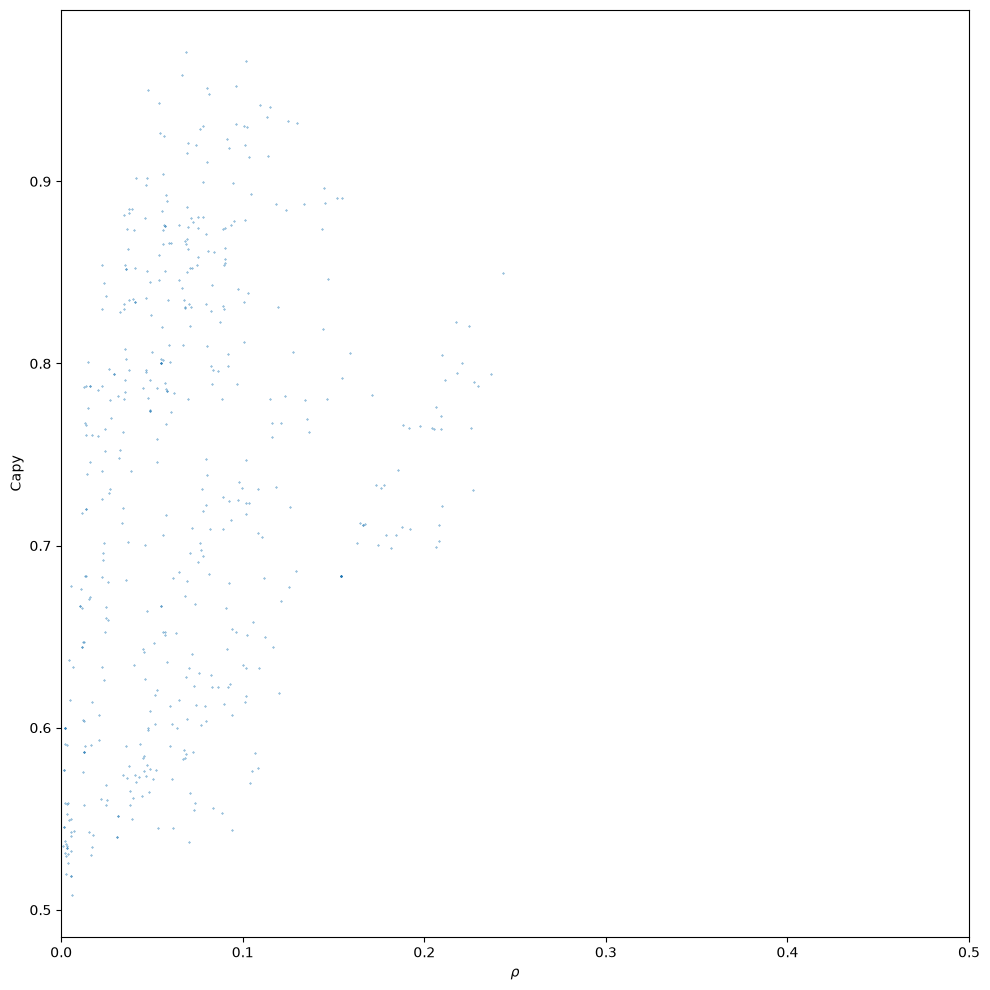

In [108]:
plt.figure(figsize=(10, 10))
plt.scatter(real_rhos, morans, s=0.1)
plt.xlabel(r'$\rho$')
plt.ylabel("Moran's I")
plt.xlim([0, 0.5])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 10))
plt.scatter(real_rhos, capys, s=0.1)
plt.xlabel(r'$\rho$')
plt.ylabel("Capy")
plt.xlim([0, 0.5])
plt.tight_layout()
plt.show()

In [109]:
def generate_kclust_grid(G, rho, k):

    target_pop = rho * property_sum(G, "TOTPOP") / k 

    # remove seeds = random.sample(...) above the loop

    for _ in range(k):
        y_nodes = [node for node in G.nodes if G.nodes[node]["x_pop"] == 0]
        seed = random.choice(y_nodes)

        G, cluster_rho = populate_cluster_random(seed, G, target_pop)

    for node in G.nodes():
        if G.nodes[node]["x_pop"] == 0:
            G.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"]
    
    real_rho = (metrics.property_sum(G, "x_pop") / 
                (metrics.property_sum(G, "x_pop") + 
                 metrics.property_sum(G, "y_pop")))
    
    x_nodes = [
        node for node in G.nodes()
        if G.nodes[node]["x_pop"] > 0
        ]

    H = G.subgraph(x_nodes)

    components = nx.number_connected_components(H)

    return G, real_rho, components

In [ ]:


num_samples = 50
num_rhos = 10

g = gerrychain.Graph.from_json("reproduction_data/ia_files/ia_counties_2020.json")

real_rhos = []
capys = []
morans =[]


for _ in range(num_samples):
    for rho in np.linspace(.001, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        nodes = list(g.nodes())
        seed = random.choice(nodes)
        g_, real_rho, num_components = generate_kclust_grid(g, rho, k=10)
        real_rhos.append(real_rho)
        capys.append(metrics.half_edge(g_, "y_pop", "x_pop"))
        morans.append(metrics.moran(g_, "x_pop", "TOTPOP")["moran_A"])

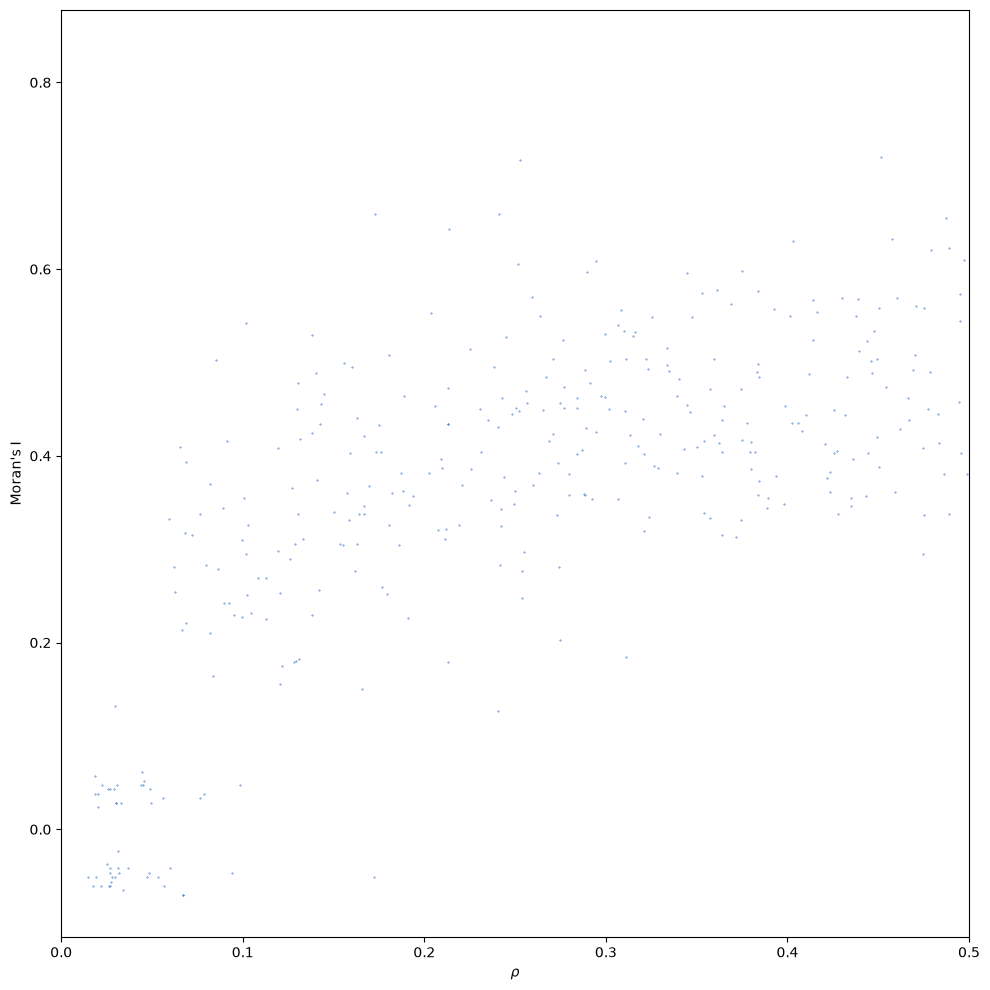

In [116]:
plt.figure(figsize=(10, 10))
plt.scatter(real_rhos, morans, s=0.1, color = "#1560bd")
plt.xlabel(r'$\rho$')
plt.ylabel("Moran's I")
plt.xlim([0, 0.5])
plt.tight_layout()
plt.show()


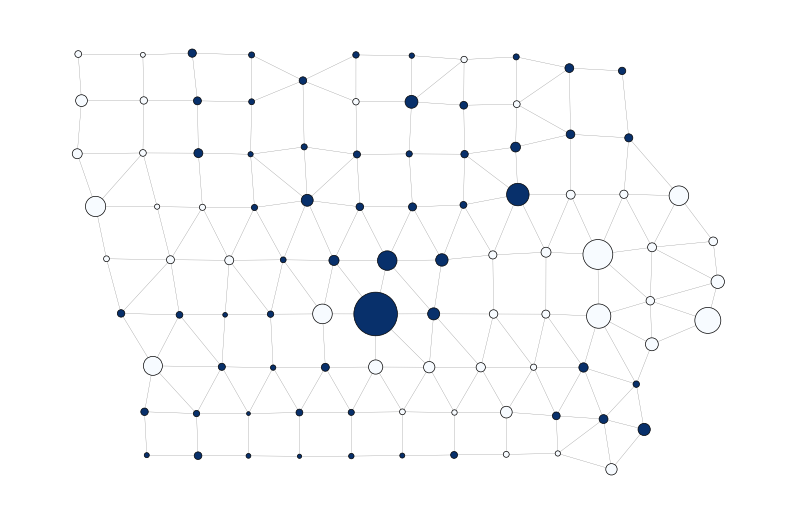

In [121]:
for node in g.nodes():
    g.nodes[node]["x_pop"] = 0
    g.nodes[node]["y_pop"] = 0

